# **Atividade Prática:** Pré-processamento e Análise de Dados de Marketing


**Objetivo:** Realizar a limpeza, análise exploratória gráfica e preparação dos dados para modelos de Machine Learning, baseando-se no framework de [Data Preprocessing in Machine Learning](https://www.kaggle.com/code/alirezahasannejad/data-preprocessing-in-machine-learning).

## **Passo 1 & 2: Importação de Bibliotecas e Preparação**

Nesta etapa, preparamos o ambiente com as ferramentas essenciais para manipulação de dados, visualização e modelagem.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 

## **Passo 3: Importação do Dataset**
O arquivo Customer marketing.csv utiliza tabulação (\t) como separador. Vamos carregá-lo e realizar uma inspeção inicial.

In [3]:
current_path = os.getcwd()
current_path

'c:\\Users\\henrique.cordeiro\\OneDrive - Sociedade Campineira de Educação e Instrução\\A-POS\\LINGUAGEM DE PROGRAMAÇÃO PYTHON APLICADA A MACHINE LEARNING'

In [4]:
df_customer = pd.read_csv(os.path.join(current_path,"Customer marketing.csv"),  sep="\t")
df_customer

,ID_,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [5]:
print(df_customer.head())

    ID_  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

**Pergunta 1:** Quantos registros (linhas) e variáveis (colunas) o dataset possui? Quais variáveis são numéricas e quais são categóricas?

In [6]:
len(df_customer)

2240

In [7]:
df_customer.describe()

,ID_,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [8]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_                  2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

**ATENÇÃO** Aqui você precisará mudar o link "'/content/drive/...'" para o caminho que o arquivo estará no seu drive ou máquina.

### Análise Gráfica Inicial (Exploratória)

Antes de processar, precisamos "conhecer" os dados. Siga as instruções abaixo para gerar visualizações.

- **Pergunta 2:** Analisando o histograma de Income, você nota a presença de valores extremos (outliers)? Como esses valores podem impactar o cálculo da média?

(array([5.480e+02, 1.106e+03, 5.490e+02, 5.000e+00, 7.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([  1730. ,  34976.8,  68223.6, 101470.4, 134717.2, 167964. ,
        201210.8, 234457.6, 267704.4, 300951.2, 334198. , 367444.8,
        400691.6, 433938.4, 467185.2, 500432. , 533678.8, 566925.6,
        600172.4, 633419.2, 666666. ]),
 <BarContainer object of 20 artists>)

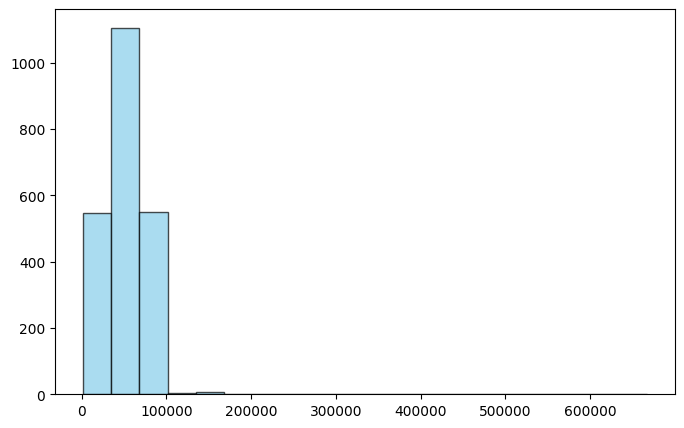

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(
    df_customer["Income"],
    bins=20,              # Número de "caixas" (intervalos)
    color='skyblue',      # Cor das barras
    edgecolor='black',    # Cor da borda das barras
    alpha=0.7             # Transparência
)

C:\Users\henrique.cordeiro\AppData\Local\Temp\ipykernel_16672\1465954505.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


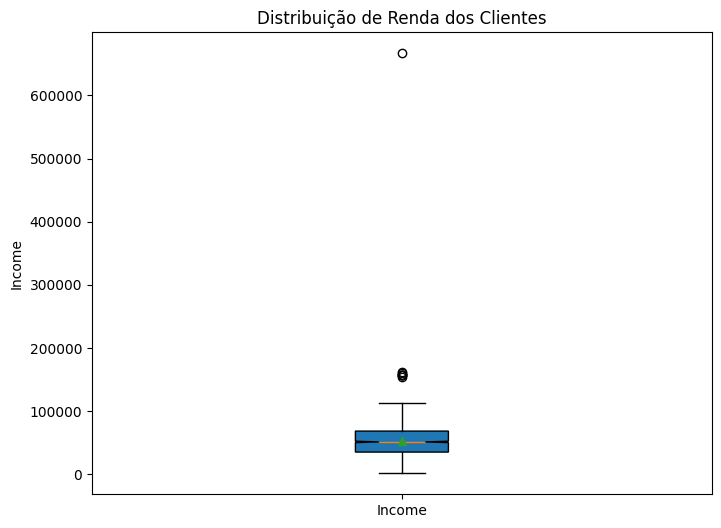

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

box = ax.boxplot(
    df_customer["Income"].dropna(),  
    labels=["Income"],             
    patch_artist=True,               
    notch=True,                     
    showmeans=True                   # mostrar média
)

ax.set_title("Distribuição de Renda dos Clientes")
ax.set_ylabel("Income")

plt.show()

Esse outliers encontrados no income distocem a media, devia que o calculo é feito com conjunto todo

- **Pergunta 3:** Qual nível de escolaridade parece apresentar a maior mediana de renda?

<Figure size 800x600 with 0 Axes>

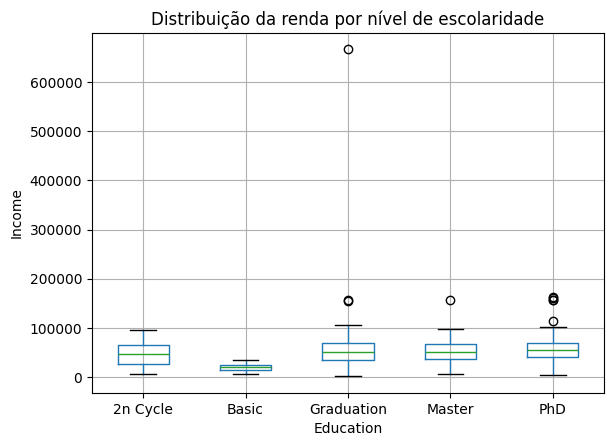

In [11]:
plt.figure(figsize=(8,6))
df_customer.boxplot(column="Income", by="Education")

plt.title("Distribuição da renda por nível de escolaridade")
plt.suptitle("")
plt.ylabel("Income")
plt.show()

In [12]:
median_income = df_customer.groupby("Education")["Income"].median()
median_income

Education
2n Cycle      46805.0
Basic         20744.0
Graduation    52028.5
Master        50943.0
PhD           55212.0
Name: Income, dtype: float64

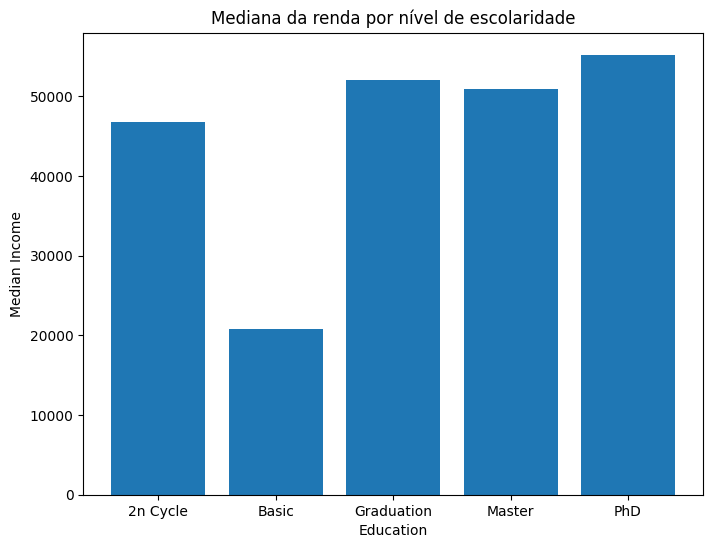

In [13]:

plt.figure(figsize=(8,6))
plt.bar(median_income.index, median_income.values)

plt.title("Mediana da renda por nível de escolaridade")
plt.xlabel("Education")
plt.ylabel("Median Income")

plt.show()

## **Passo 4: Identificando e Tratando Valores Ausentes**

Dados do mundo real costumam ser incompletos. Vamos verificar a integridade da nossa base.

- **Pergunta 4:** A coluna Income possui valores nulos. Sabendo que existem outliers (vistos no Passo Anterior), qual estratégia de preenchimento é mais segura: Média ou Mediana? Por quê?

**Tarefa Prática:** Implemente o preenchimento dos valores nulos na coluna Income utilizando a estratégia escolhida (na pergunta 4).

A mais segura em dados que possuem outilirs, seria a mediana onde que ela não seria influeciada pelo outilrs em seu  calculo vai usar o valores centrais do dataset, e para preencer todos os nulas será melhor um calculo sem essa influencia  

In [14]:
# calcular a mediana da coluna Income
median_income = df_customer["Income"].median()
median_income

np.float64(51381.5)

In [15]:
# preencher os valores nulos com a mediana
df_customer["Income"].fillna(median_income, inplace=True)
df_customer

C:\Users\henrique.cordeiro\AppData\Local\Temp\ipykernel_16672\2193636367.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_customer["Income"].fillna(median_income, inplace=True)


,ID_,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [16]:
print(df_customer["Income"].isnull().sum())

0


## **Passo 5:** Codificação de Dados Categóricos
Modelos matemáticos exigem números. Variáveis como Education e Marital_Status precisam ser transformadas.

- **Pergunta 5:** Explique a diferença entre OneHotEncoding e OrdinalEncoding. Em que situação o OrdinalEncoding seria preferível para a coluna Education?

O One-Hot Encoding cria uma coluna falso e positivo (0 ou 1) para cada categoria existente na variável da coluna do dataset.

Quando não existe ordem natural entre as categorias

O Ordinal Encoding transforma cada categoria em um número inteiro, respeitando uma possível ordem crescente ou decrescente. 

O Ordinal Encoding é preferível quando possuem uma ordem natural de progressão como (sequencia de filme, patente e elo): 

Nesse caso, faz sentido representar os níveis como números crescentes, pois há hierarquia educacional. Isso pode ajudar alguns modelos entender essa progressão sem precisar criar várias colunas.


In [ ]:
education_order = {
    "Basic": 0,
    "2n Cycle": 1,
    "Graduation": 2,
    "Master": 3,
    "PhD": 4
}

df_customer["Education"] = df_customer["Education"].map(education_order)

df_customer = pd.get_dummies(df_customer, columns=["Marital_Status"])


In [18]:
df_customer

,ID_,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Z_Revenue,Response,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,1957,2,58138.0,0,0,04-09-2012,58,635,88,...,11,1,False,False,False,False,True,False,False,False
1,2174,1954,2,46344.0,1,1,08-03-2014,38,11,1,...,11,0,False,False,False,False,True,False,False,False
2,4141,1965,2,71613.0,0,0,21-08-2013,26,426,49,...,11,0,False,False,False,False,False,True,False,False
3,6182,1984,2,26646.0,1,0,10-02-2014,26,11,4,...,11,0,False,False,False,False,False,True,False,False
4,5324,1981,4,58293.0,1,0,19-01-2014,94,173,43,...,11,0,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,2,61223.0,0,1,13-06-2013,46,709,43,...,11,0,False,False,False,True,False,False,False,False
2236,4001,1946,4,64014.0,2,1,10-06-2014,56,406,0,...,11,0,False,False,False,False,False,True,False,False
2237,7270,1981,2,56981.0,0,0,25-01-2014,91,908,48,...,11,0,False,False,True,False,False,False,False,False
2238,8235,1956,3,69245.0,0,1,24-01-2014,8,428,30,...,11,0,False,False,False,False,False,True,False,False
